# Figure — R² Performance: Original Dataset vs Age ≥ 60 Cohort

Grouped bar chart comparing bootstrap-estimated R² (± 95% CI) for the PPG model
evaluated on the full test set versus the Age ≥ 60 subgroup.

Data source: `PERFORMANCE_RESULTS_PAPER / Bootstrap / ppg` and `age_stratified / age_gte60`.

In [5]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path("../").resolve()))

from fig_style import (
    DPI, W_FULL, W_SINGLE, ASPECT, FONT_FAMILY,
    MIN_PX_FULL, MIN_PX_SINGLE,
    apply_base_style, save_fig,
)
from local_paths import PERFORMANCE_RESULTS_PAPER, FIGURES_PAPER

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

FIG_OUT = FIGURES_PAPER
FIG_OUT.mkdir(parents=True, exist_ok=True)
print(f"Output directory : {FIG_OUT.resolve()}")
print(f"Full-page  : {W_FULL:.2f} x {W_FULL*ASPECT:.2f} in  ->"
      f"  {round(W_FULL*DPI)} x {round(W_FULL*ASPECT*DPI)} px @ {DPI} dpi")

Output directory : C:\Users\addp972\OneDrive - City, University of London\3.PhD\9. Experiments\2.LightGBM_SHAP\Figures_SummaryTables
Full-page  : 7.48 x 4.86 in  ->  3740 x 2431 px @ 500 dpi


## 1 · Config & data loading

In [6]:
METRIC  = "R2"
SCALE   = 100.0
TARGETS = ["SBP", "DBP", "MAP"]

BOOT_ROOT = PERFORMANCE_RESULTS_PAPER / "Bootstrap"

MODELS = [
    {
        "key":   "ppg",
        "label": "Original",
        "color": "#5D2E8C",   # steel blue
    },
    {
        "key":   "age_stratified/age_gte60",
        "label": "Age \u226560",
        "color": "#F1E8B8",   # amber
    },
]

BAR_W = 0.35


def load_ci(model_key: str, target: str) -> tuple:
    """Return (point_estimate, ci_lower, ci_upper) scaled to %."""
    path = BOOT_ROOT / model_key / f"CI_{target}.csv"
    df   = pd.read_csv(path, sep=";")
    row  = df[df["metric"] == METRIC].iloc[0]
    return (
        float(row["point_estimate"]) * SCALE,
        float(row["ci_lower"])       * SCALE,
        float(row["ci_upper"])       * SCALE,
    )


# Pre-load all values
ci_table = {}
for model in MODELS:
    ci_table[model["key"]] = {}
    for target in TARGETS:
        pt, lo, hi = load_ci(model["key"], target)
        ci_table[model["key"]][target] = (pt, lo, hi)
        print(f"  {model['key']:35s}  {target}: {pt:.2f}%  95% CI [{lo:.2f}%, {hi:.2f}%]")

  ppg                                  SBP: 19.94%  95% CI [14.12%, 25.42%]
  ppg                                  DBP: 19.49%  95% CI [12.01%, 25.87%]
  ppg                                  MAP: 24.97%  95% CI [17.74%, 31.72%]
  age_stratified/age_gte60             SBP: 16.52%  95% CI [7.77%, 24.29%]
  age_stratified/age_gte60             DBP: 13.81%  95% CI [4.42%, 21.79%]
  age_stratified/age_gte60             MAP: 21.76%  95% CI [11.96%, 29.97%]


## 2 · Plot

Full-page  : 3740 x 2431 px
Single-col : 1770 x 1150 px


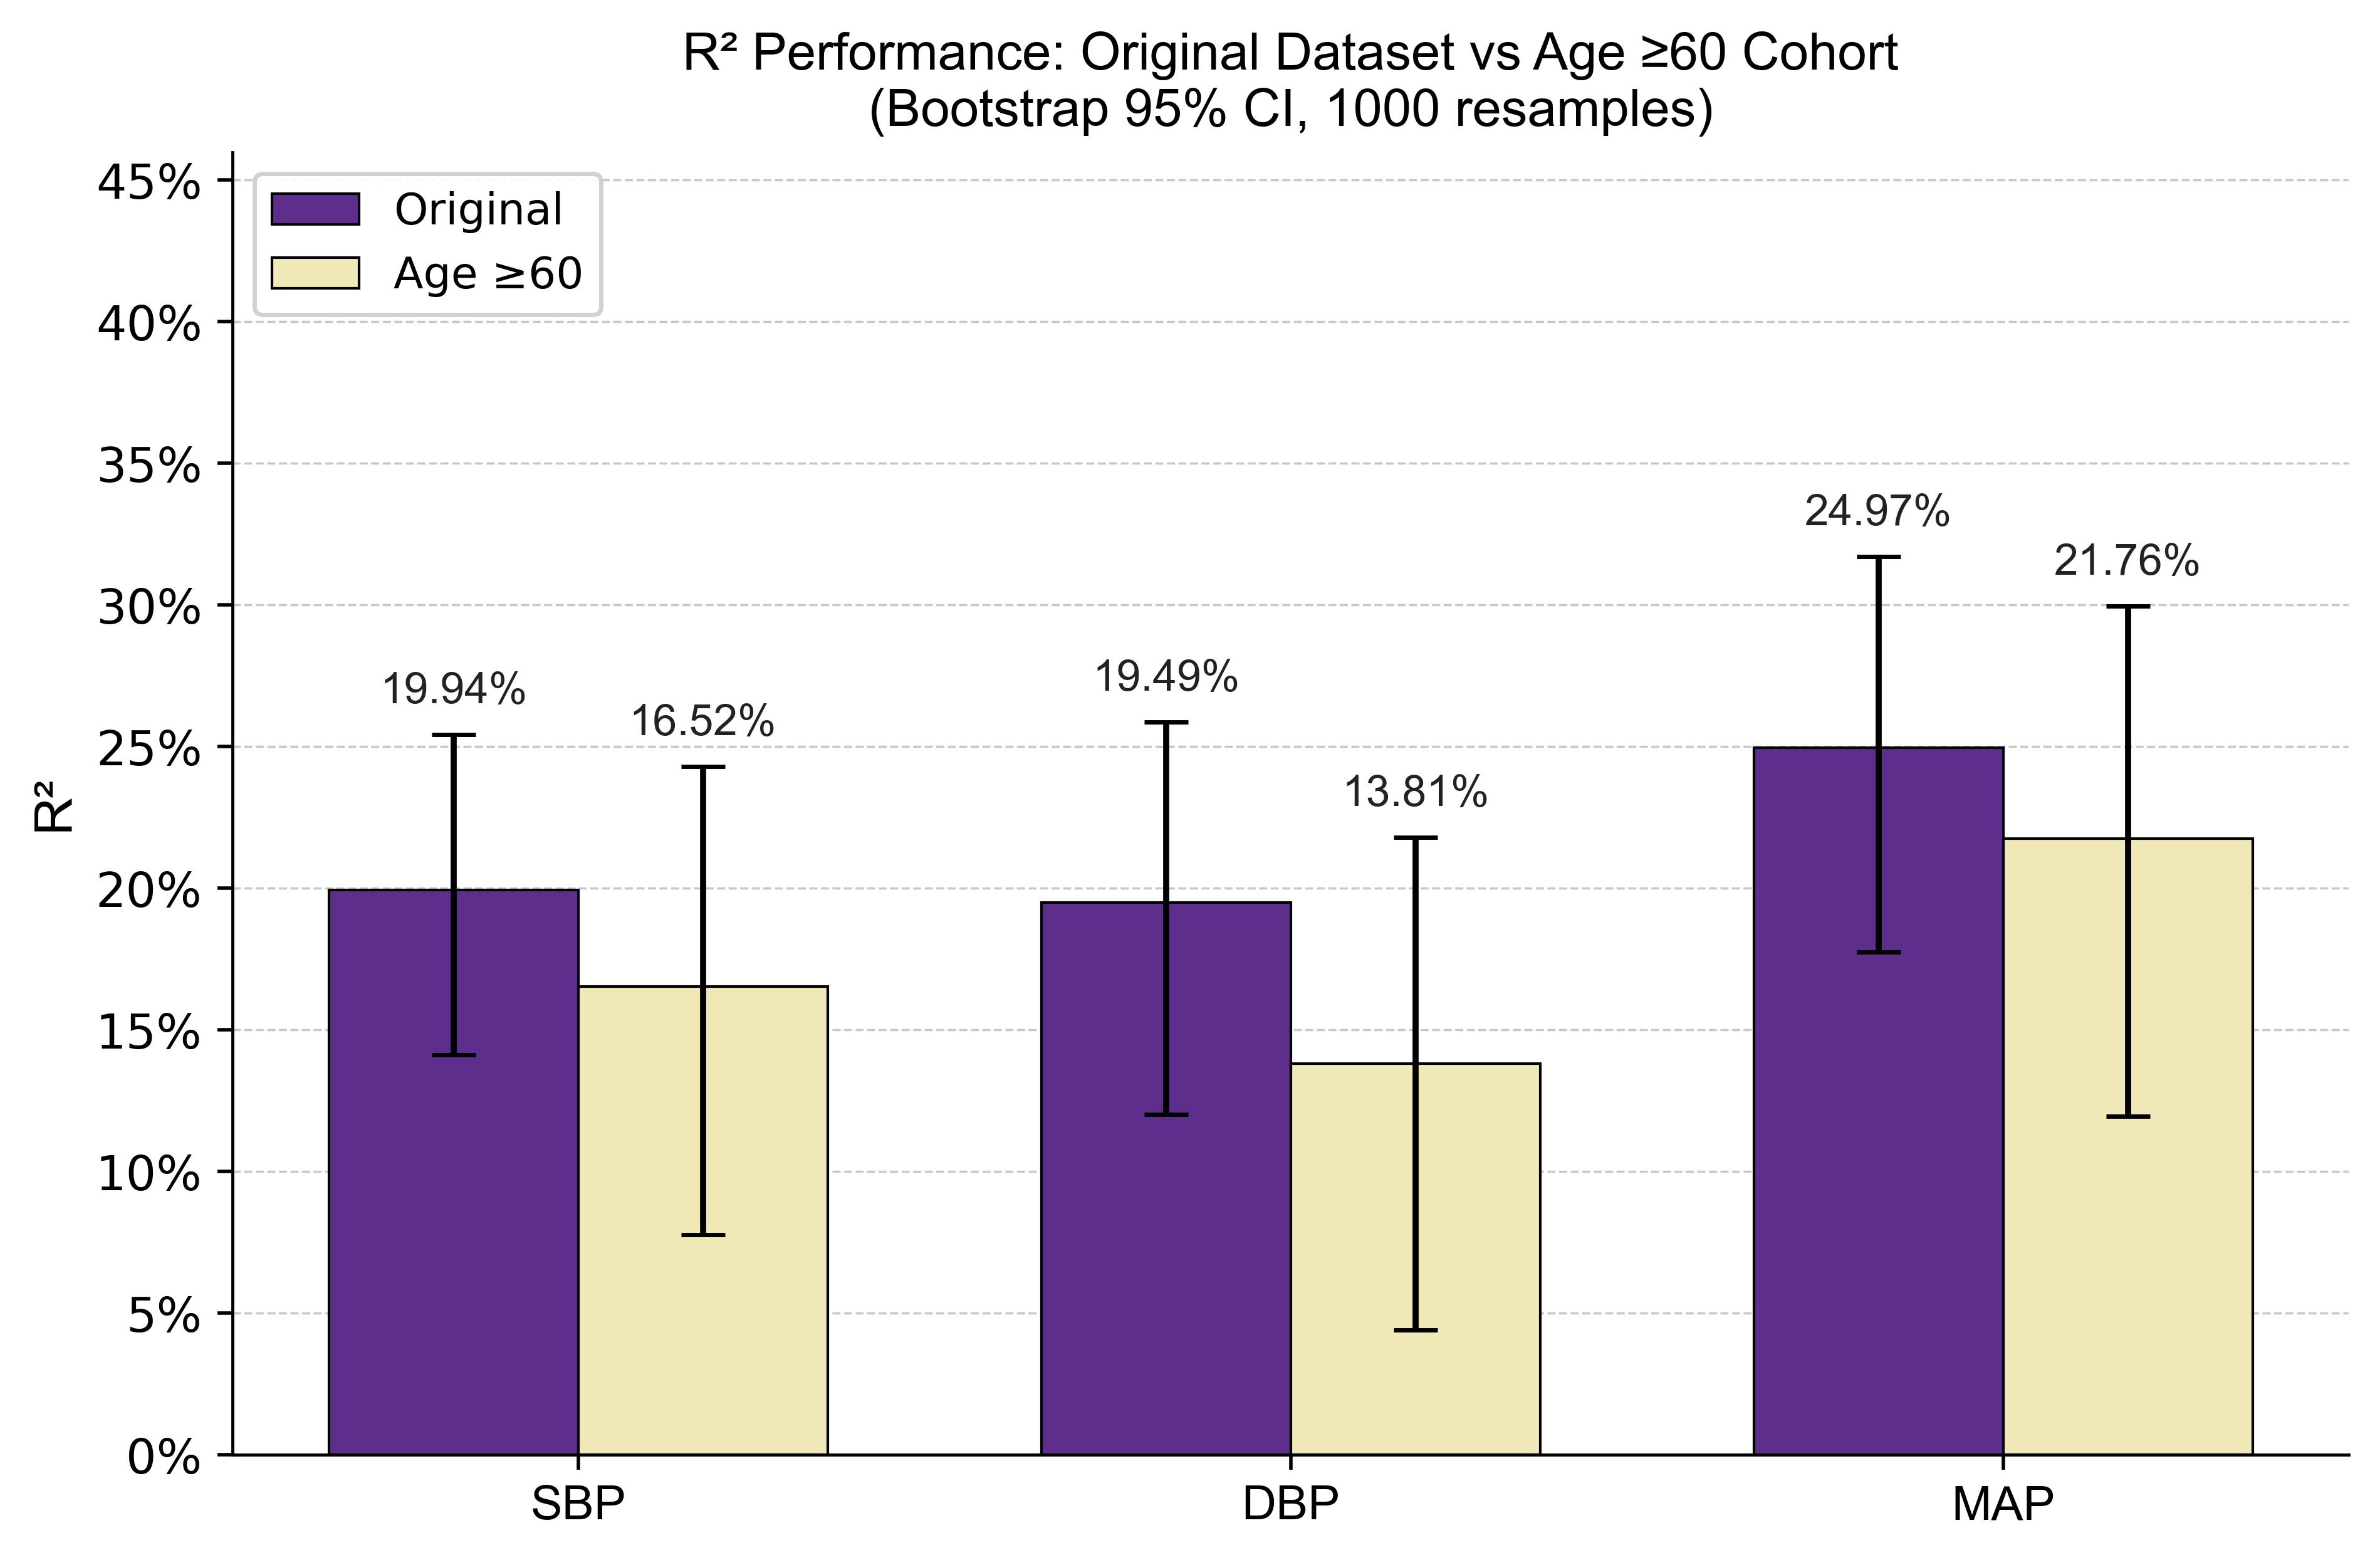

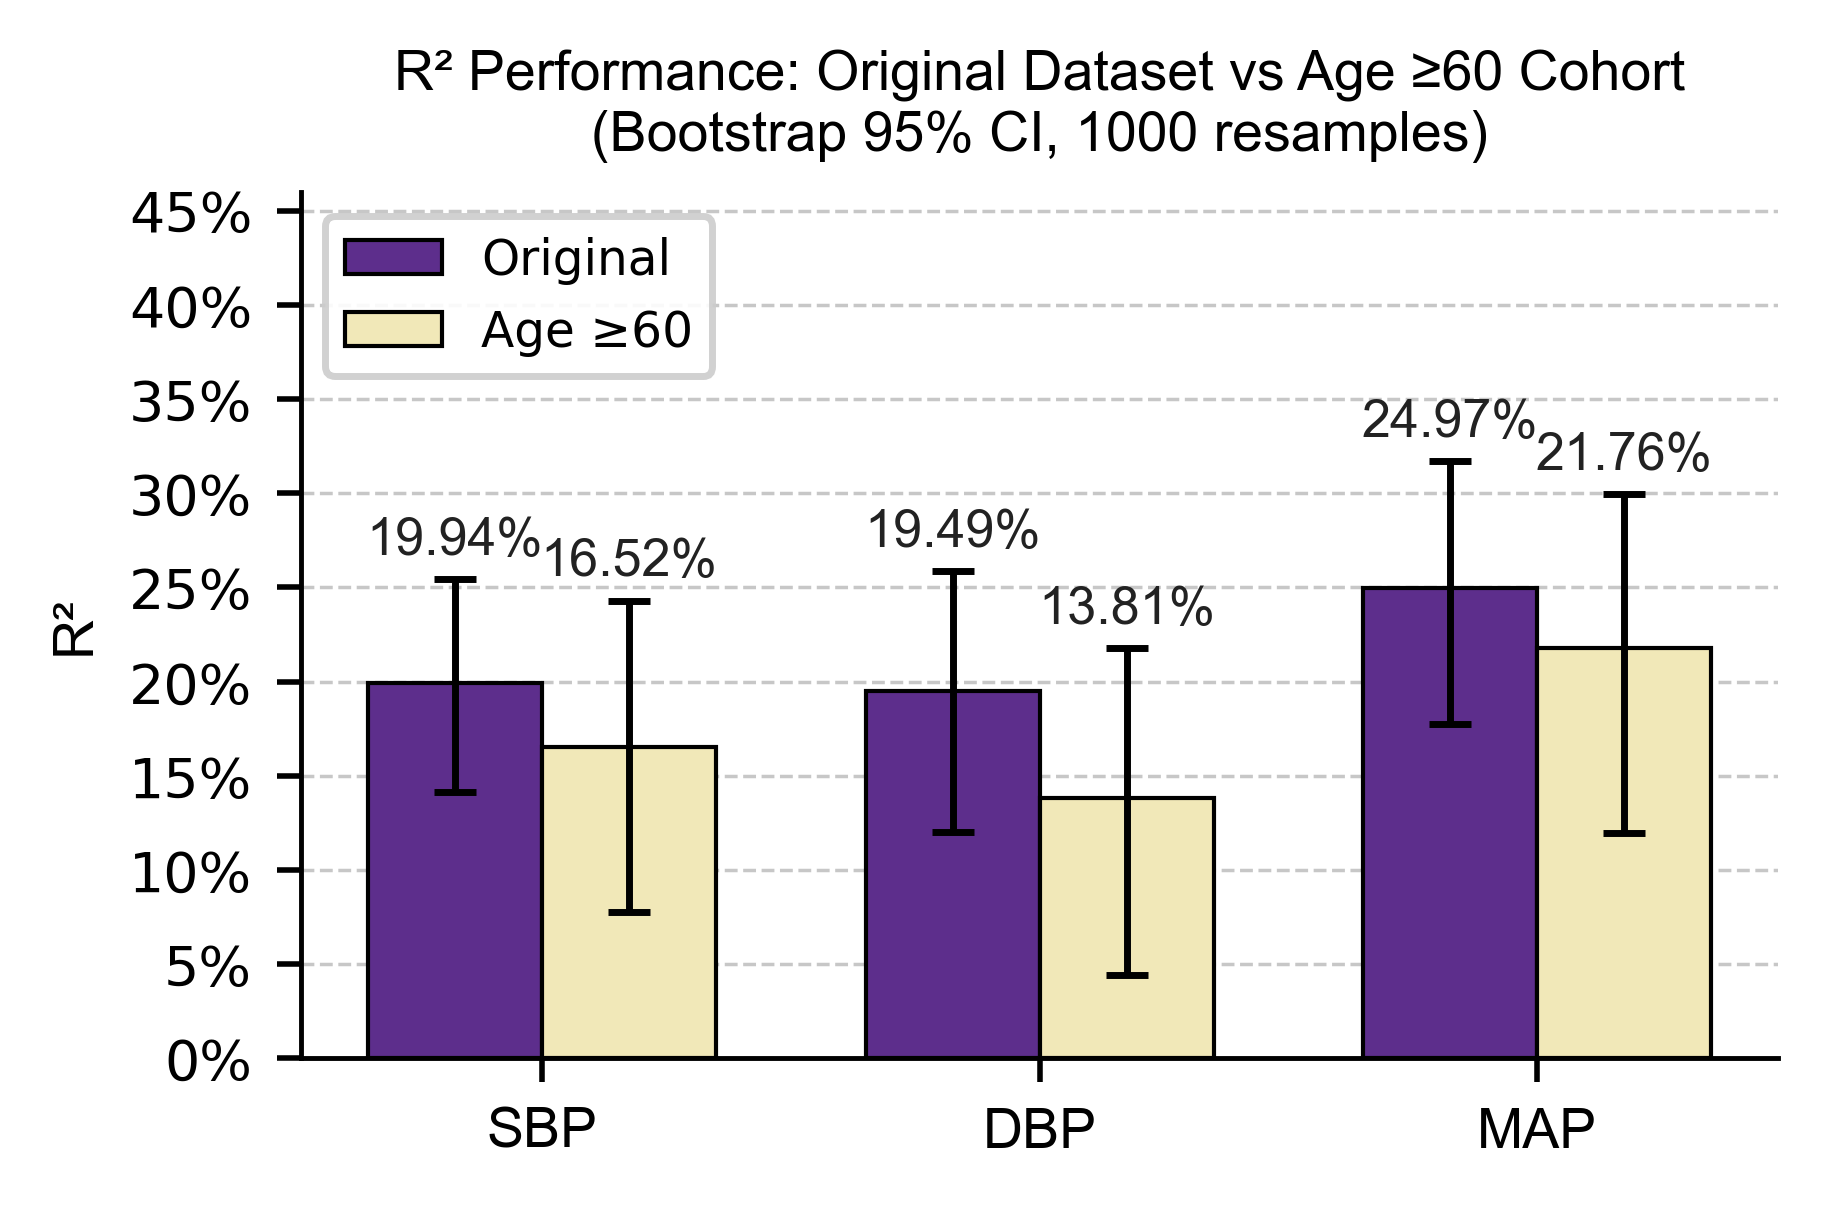

In [7]:
x       = np.arange(len(TARGETS))
offsets = [-BAR_W / 2, BAR_W / 2]


def make_fig(width_in: float):
    is_small = width_in < 5
    label_fs = 7.5 if is_small else 10.0
    tick_fs  = 8   if is_small else 11
    title_fs = 8   if is_small else 12
    leg_fs   = 7   if is_small else 10
    cap_sz   = 3   if is_small else 5
    err_lw   = 1.0 if is_small else 1.4

    height_in = width_in * ASPECT
    fig, ax = plt.subplots(
        figsize=(width_in, height_in), dpi=DPI, layout="constrained"
    )

    all_uppers = []

    for model, offset in zip(MODELS, offsets):
        pts      = [ci_table[model["key"]][t][0] for t in TARGETS]
        lows     = [ci_table[model["key"]][t][0] - ci_table[model["key"]][t][1] for t in TARGETS]  # pt - lo
        highs    = [ci_table[model["key"]][t][2] - ci_table[model["key"]][t][0] for t in TARGETS]  # hi - pt
        ci_upper = [ci_table[model["key"]][t][2] for t in TARGETS]
        all_uppers.extend(ci_upper)

        # Bars
        ax.bar(
            x + offset, pts, BAR_W,
            color=model["color"], label=model["label"],
            edgecolor="black", linewidth=0.6, zorder=3,
        )

        # Asymmetric error bars
        ax.errorbar(
            x + offset, pts,
            yerr=[lows, highs],
            fmt="none", color="black",
            capsize=cap_sz, linewidth=err_lw, zorder=4,
        )

        # Point estimate labels above the CI upper bound
        for i, (pt, hi_abs) in enumerate(zip(pts, ci_upper)):
            ax.text(
                x[i] + offset, hi_abs + 0.8,
                f"{pt:.2f}%",
                ha="center", va="bottom",
                fontsize=label_fs, fontfamily=FONT_FAMILY,
                color="#222222",
            )

    # Axes
    y_max = max(all_uppers)
    ax.set_ylim(0, y_max * 1.45)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
    ax.set_xticks(x)
    ax.set_xticklabels(TARGETS, fontsize=tick_fs, fontfamily=FONT_FAMILY)
    ax.set_ylabel("R²", fontsize=title_fs, fontfamily=FONT_FAMILY)

    ax.legend(
        loc="upper left", fontsize=leg_fs,
        frameon=True, framealpha=0.9, edgecolor="#CCCCCC",
    )

    ax.set_title(
        "R² Performance: Original Dataset vs Age \u226560 Cohort\n"
        "(Bootstrap 95% CI, 1000 resamples)",
        fontsize=title_fs, fontfamily=FONT_FAMILY, pad=6,
    )

    apply_base_style(ax, grid_axis="y")
    ax.tick_params(axis="both", labelsize=tick_fs)
    return fig


fig_full   = make_fig(W_FULL)
fig_single = make_fig(W_SINGLE)

save_fig(fig_full,   "Fig_Bootstrap_Age60_Comparison_full",   FIG_OUT)
save_fig(fig_single, "Fig_Bootstrap_Age60_Comparison_single", FIG_OUT)

print(f"Full-page  : {round(W_FULL*DPI)} x {round(W_FULL*ASPECT*DPI)} px")
print(f"Single-col : {round(W_SINGLE*DPI)} x {round(W_SINGLE*ASPECT*DPI)} px")
plt.show()

## 3 · Verify pixel counts

In [8]:
from PIL import Image

for fname, req_w in [
    ("Fig_Bootstrap_Age60_Comparison_full.png",   MIN_PX_FULL),
    ("Fig_Bootstrap_Age60_Comparison_single.png", MIN_PX_SINGLE),
]:
    with Image.open(FIG_OUT / fname) as im:
        w, h = im.size
    ok = "\u2705" if w >= req_w else "\u274c"
    print(f"{ok} {fname}: {w} x {h} px  (min required: {req_w} px wide)")

✅ Fig_Bootstrap_Age60_Comparison_full.png: 3798 x 2489 px  (min required: 3740 px wide)
✅ Fig_Bootstrap_Age60_Comparison_single.png: 1828 x 1208 px  (min required: 1772 px wide)
